 #.Prédiction de maladie cardiaque avec un Perceptron Multicouche (MLP)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# accuracy_score          : taux global de bonnes prédictions
# precision_score         : parmi les prédits "malade", combien le sont vraiment
# recall_score            : parmi les vrais "malade", combien sont détectés
# f1_score                : moyenne harmonique précision/rappel
# confusion_matrix        : tableau résumant vrais/faux positifs/négatifs
# classification_report   : résumé combiné de toutes ces métriques, par classe

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
df = pd.read_csv("heart.csv")

In [6]:
#Afficher les premières lignes
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


age → âge du patient
sex → sexe
cp → type de douleur thoracique
trestbps → pression artérielle au repos
chol → cholestérol
fbs → glycémie à jeun
thalach → fréquence cardiaque maximale
exang → angine provoquée par exercice
oldpeak → dépression ST
target → présence maladie cardiaque

In [7]:
print("Shape :", df.shape)
print("\nColonnes :")
print(df.columns)

print("\nInformations :")
df.info()

Shape : (1025, 14)

Colonnes :
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

Informations :
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.isnull().sum() #Vérifier valeurs manquantes

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [ ]:
df.describe() ## Statistiques descriptives (moyenne, écart-type, min, max, quartiles) de chaque variable numérique

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


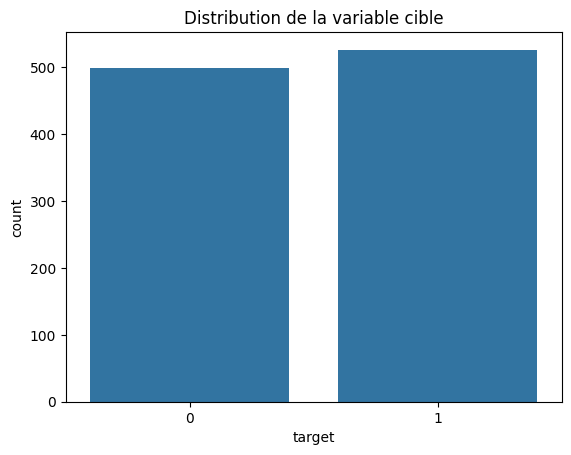

In [ ]:
sns.countplot(x='target', data=df)
plt.title("Distribution de la variable cible")
plt.show()
#0 → pas de maladie
#1 → maladie cardiaque
# Permet de vérifier si les classes sont équilibrées.

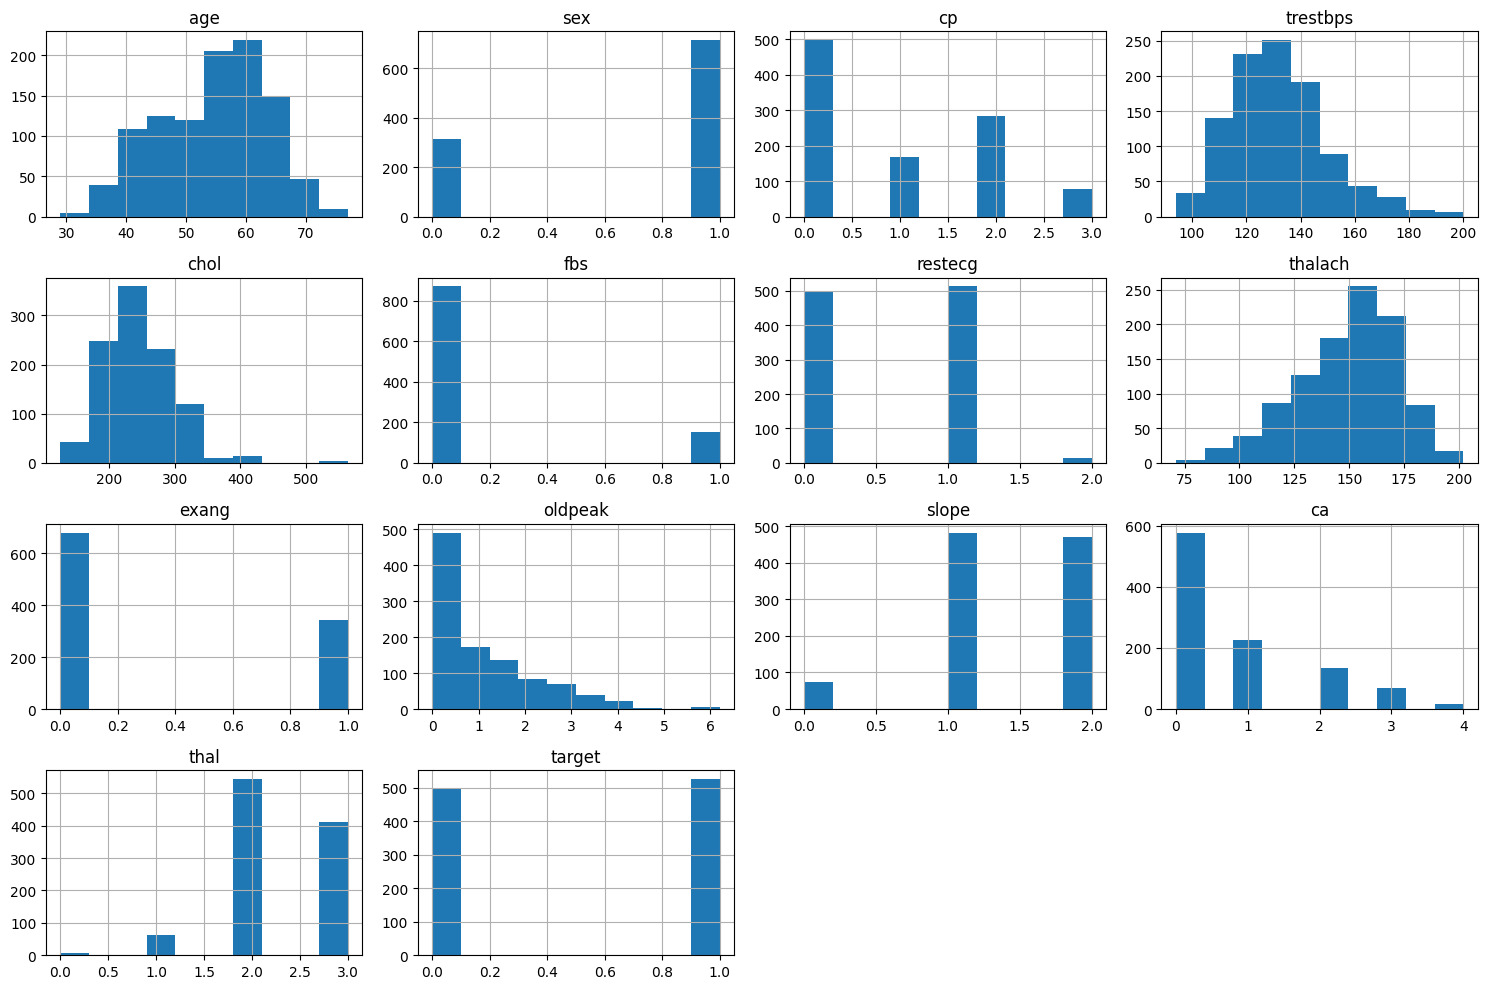

In [ ]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()
#Ça montre la distribution des variables.
# Permet de repérer la forme (normale, asymétrique...) et l'échelle de chaque variable

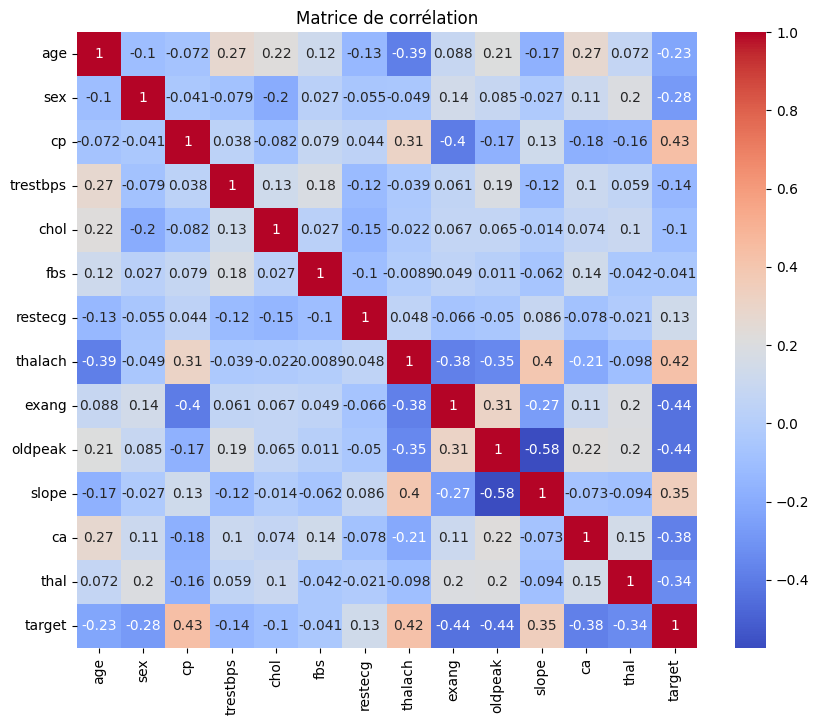

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()
# Mesure la corrélation linéaire entre chaque paire de variables (entre -1 et 1)
# Permet de repérer les variables les plus liées à 'target' (potentiellement les plus informatives)

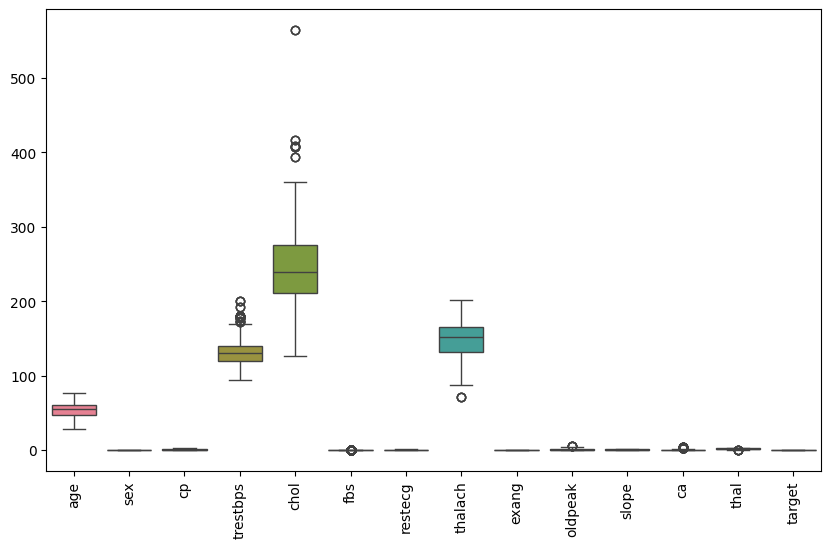

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()
#Pour détecter les outliers
# Les points en dehors des moustaches sont des valeurs extrêmes potentielles

Prétraitement
1. Séparer les variables explicatives (X) de la variable cible (y)
2. Diviser les données en ensembles **train / validation / test**
3. **Normaliser** les variables (`StandardScaler`)
4. Convertir les données en **tenseurs PyTorch**
5. Envoyer les tenseurs sur le **device** (CPU ou GPU)

In [ ]:
#Séparer features et target
#X → features ,y → target (X→inputs,y→output)
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
#Split Train / Test
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
#'''70% train 30% temporaire (validation + test)'''
# random_state=42 : graine aléatoire fixe -> split reproductible à chaque exécution
# stratify=y      : conserve la même proportion de classes 0/1 dans train et temp que dans le dataset original
#                    (évite un déséquilibre de classes après le découpage)

In [ ]:
#Split Validation / Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
# On coupe les 30% restants en 2 parts égales -> 15% validation / 15% test
# Répartition finale : 70% train / 15% validation / 15% test
# - train      : sert à entraîner (mettre à jour) les poids du modèle
# - validation : sert à surveiller la performance PENDANT l'entraînement, sans toucher au test
# - test       : sert à évaluer la performance finale, jamais vu pendant l'entraînement

In [ ]:
#Normalisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
# Important : fit_transform UNIQUEMENT sur X_train, puis transform (sans fit) sur val/test
# -> évite la fuite de données (data leakage) : le modèle ne doit jamais "voir" les statistiques du test
# La normalisation (moyenne 0, écart-type 1) aide le réseau de neurones à converger plus vite et plus stablement

In [ ]:
#Conversion en tenseurs PyTorch
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
# float32 : type standard pour les features en entrée d'un réseau de neurones

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)
# long (int64) : type attendu par nn.CrossEntropyLoss pour les labels de classification
# (chaque label est un indice de classe : 0 ou 1, pas une valeur continue)

In [ ]:
#Device (CPU / GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# Si un GPU compatible CUDA est disponible, on l'utilise (calcul plus rapide), sinon on reste sur CPU

cpu


In [ ]:
#Envoyer les données vers device
X_train, y_train = X_train.to(device), y_train.to(device)
X_val, y_val = X_val.to(device), y_val.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
# Les tenseurs doivent être sur le même device que le modèle, sinon PyTorch lève une erreur
# au moment du calcul (ex: modèle sur GPU mais données sur CPU)

## Modèle 1 : `nn.Sequential`

`nn.Sequential` permet de définir un réseau comme un simple empilement de couches exécutées les unes après les autres, dans l'ordre où elles sont déclarées. C'est la façon la plus rapide de définir un MLP simple (sans branches ni logique conditionnelle dans le passage des données).

In [ ]:
#Modèle
import torch.nn as nn

input_dim = X_train.shape[1] # nombre de features en entrée = nombre de colonnes de X
num_classes = 2 # classification binaire : 0 (pas de maladie) ou 1 (maladie)

model_seq = nn.Sequential(

# couche entièrement connectée : input_dim -> 128 neurones
# activation non-linéaire : ReLU(x) = max(0, x)
# normalise les activations du batch -> entraînement plus stable et plus rapide
# désactive aléatoirement 30% des neurones à chaque passage -> réduit l'overfitting

    nn.Linear(input_dim, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.Dropout(0.3),

    nn.Linear(64, num_classes)
)# Pas de Softmax en sortie : nn.CrossEntropyLoss applique elle-même un LogSoftmax en interne

In [ ]:
#Loss + Optimizer
import torch.optim as optim
# CrossEntropyLoss : fonction de perte standard pour la classification multi-classe
# (combine LogSoftmax + Negative Log-Likelihood Loss en une seule étape)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_seq.parameters(), lr=0.001)
# Adam : algorithme d'optimisation à taux d'apprentissage adaptatif
# (converge en général plus vite et plus stablement qu'une descente de gradient classique SGD)
# lr=0.001 : taille du pas de mise à jour des poids à chaque itération

In [ ]:
#Training loop
epochs = 50

for epoch in range(epochs):
    model_seq.train() # mode entraînement : active Dropout, BatchNorm utilise les stats du batch courant

 # forward pass : calcule les prédictions sur tout le train
  # calcule l'erreur entre prédictions et vraies étiquettes

    outputs = model_seq(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

 # réinitialise les gradients (sinon ils s'accumuleraient à chaque itération)
  # rétropropagation : calcule le gradient de la loss par rapport à chaque poids
  # met à jour les poids du modèle selon les gradients calculés


    # validation
    model_seq.eval()
# mode évaluation : désactive Dropout, BatchNorm utilise les stats apprises (pas celles du batch)
  # désactive le calcul des gradients (inutile en validation -> plus rapide, moins de mémoire)
      
    with torch.no_grad():
        val_outputs = model_seq(X_val)
        val_loss = criterion(val_outputs, y_val)

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {loss.item():.4f} "
              f"Val Loss: {val_loss.item():.4f}")
# Remarque : tout le train set est utilisé en une seule fois à chaque époque
# (pas de mini-batchs / DataLoader ici, donc "full-batch gradient descent")

Epoch [10/50] Train Loss: 0.3930 Val Loss: 0.4548
Epoch [20/50] Train Loss: 0.3363 Val Loss: 0.3109
Epoch [30/50] Train Loss: 0.2877 Val Loss: 0.2498
Epoch [40/50] Train Loss: 0.2405 Val Loss: 0.2124
Epoch [50/50] Train Loss: 0.2184 Val Loss: 0.1856


## Modèle 2 : classe personnalisée (`nn.Module`)

On redéfinit le **même réseau**, mais cette fois en créant une classe Python héritant de `nn.Module`. Cette approche est plus flexible que `nn.Sequential` : elle permet de définir un `forward` personnalisé (boucles, conditions, branches multiples, connexions résiduelles, etc.), ce qui devient indispensable pour des architectures plus complexes qu'un simple empilement de couches.

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        # super().__init__() initialise les mécanismes internes de nn.Module
        # (indispensable pour que PyTorch puisse enregistrer/suivre les paramètres des couches définies ci-dessous)

        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)

        self.fc3 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()

    def forward(self, x):
          # forward définit le chemin que suivent les données à travers le réseau (équivalent du nn.Sequential)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x
    # Cette classe définit exactement la même architecture que model_seq (cellule du Modèle 1),
# mais de façon explicite et réutilisable : on peut l'instancier plusieurs fois (cf. comparaison des initialisations plus loin)

In [ ]:
#model = MLP(input_dim, num_classes)
model = MLP(input_dim, num_classes)
# Instanciation du modèle : crée un objet MLP avec des poids initialisés aléatoirement par défaut par PyTorch

In [ ]:
#Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Mêmes choix que pour model_seq : CrossEntropyLoss + Adam (lr=0.001)
# Mais ici optimizer.parameters() pointe vers les poids de 'model' (classe personnalisée), pas model_seq

In [ ]:
train_losses = []
val_losses = []
 # historique de la loss sur le train, à chaque époque
  # historique de la loss sur la validation, à chaque époque
# Ces listes serviront à tracer la courbe d'apprentissage juste après l'entraînement

In [ ]:
epochs = 50

for epoch in range(epochs):
    model.train()

    # Forward train
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {loss.item():.4f} "
              f"Val Loss: {val_loss.item():.4f}")
  
  # Identique à la boucle d'entraînement du modèle Sequential, avec en plus l'enregistrement
# des pertes (train_losses / val_losses) à chaque époque, pour pouvoir tracer la courbe d'apprentissage ci-dessous

Epoch [10/50] Train Loss: 0.1628 Val Loss: 0.1372
Epoch [20/50] Train Loss: 0.1580 Val Loss: 0.1276
Epoch [30/50] Train Loss: 0.1528 Val Loss: 0.1172
Epoch [40/50] Train Loss: 0.1408 Val Loss: 0.1088
Epoch [50/50] Train Loss: 0.1278 Val Loss: 0.1005


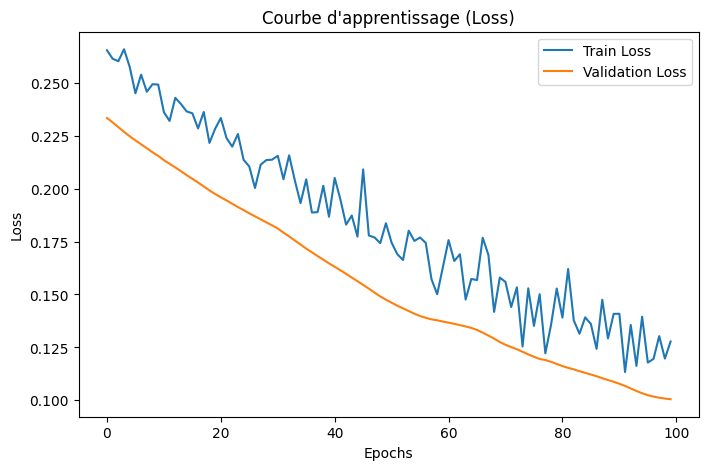

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe d'apprentissage (Loss)")
plt.legend()

plt.show()
# Lecture de la courbe :
# - les deux courbes descendent ensemble        -> le modèle apprend correctement
# - train loss continue de baisser mais val loss remonte -> signe de surapprentissage (overfitting)
# - les deux courbes stagnent haut               -> le modèle n'apprend pas assez (underfitting)

In [ ]:
#Training loop
epochs = 50

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {loss.item():.4f} "
              f"Val Loss: {val_loss.item():.4f}")
#Remarque importante (point souvent posé en question) :
# Cette cellule relance une boucle de 50 époques SANS réinitialiser 'model' ni 'optimizer'.
# L'entraînement reprend donc là où il s'était arrêté à la cellule précédente
# -> au total, 'model' aura été entraîné sur 100 époques (50 + 50), pas seulement 50.
# A garder en tête lors de la comparaison finale avec model_seq, qui lui n'a été entraîné que sur 50 époques.

Epoch [10/50] Train Loss: 0.4393 Val Loss: 0.4795
Epoch [20/50] Train Loss: 0.3591 Val Loss: 0.3360
Epoch [30/50] Train Loss: 0.3241 Val Loss: 0.2862
Epoch [40/50] Train Loss: 0.3029 Val Loss: 0.2585
Epoch [50/50] Train Loss: 0.2710 Val Loss: 0.2356


## Prédiction et évaluation sur le test set

On utilise maintenant le modèle entraîné (`model`) pour prédire sur des données qu'il n'a jamais vues (`X_test`), puis on mesure sa performance avec plusieurs métriques de classification.

In [ ]:
#Prédictions
with torch.no_grad():
    y_pred = model(X_test)
    y_pred_classes = torch.argmax(y_pred, axis=1)
      # argmax sur axis=1 (axe des classes) : renvoie l'indice (0 ou 1) du logit le plus élevé
    # -> transforme les scores bruts en une classe prédite par patient

In [ ]:
#Métriques
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test.cpu(), y_pred_classes.cpu()))
print("Precision:", precision_score(y_test.cpu(), y_pred_classes.cpu()))
print("Recall:", recall_score(y_test.cpu(), y_pred_classes.cpu()))
print("F1-score:", f1_score(y_test.cpu(), y_pred_classes.cpu()))

# .cpu() : les fonctions sklearn travaillent avec numpy/CPU, il faut donc rapatrier les tenseurs du GPU vers le CPU
# Accuracy  : proportion totale de prédictions correctes
# Precision : parmi les patients prédits "malades", proportion réellement malades (limite les faux positifs)
# Recall    : parmi les patients réellement malades, proportion détectée par le modèle (limite les faux négatifs)
# F1-score  : moyenne harmonique de precision et recall (résumé utile quand les classes ne sont pas parfaitement équilibrées)

Accuracy: 0.8376623376623377
Precision: 0.8214285714285714
Recall: 0.8734177215189873
F1-score: 0.8466257668711656


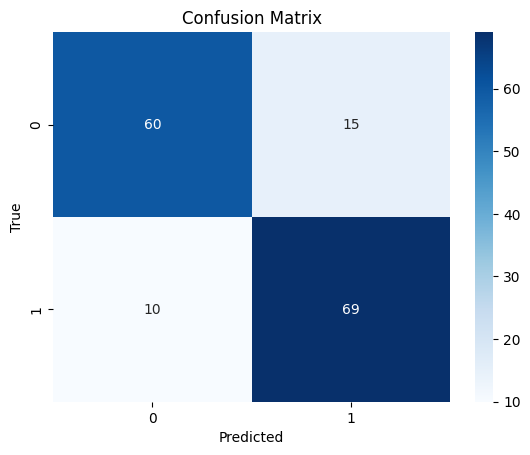

In [ ]:
#Matrice de confusion
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test.cpu(), y_pred_classes.cpu())

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# Lecture de la matrice :
# - diagonale (haut-gauche, bas-droite) : prédictions correctes (vrais négatifs, vrais positifs)
# - hors diagonale : erreurs
#     - faux positif : prédit "malade" alors que le patient est sain
#     - faux négatif : prédit "sain" alors que le patient est malade (le plus risqué en contexte médical)

## Comparaison de stratégies d'initialisation des poids

La façon dont les poids d'un réseau sont initialisés (avant le tout premier entraînement) influence la vitesse de convergence et la qualité finale du modèle. On compare ici 3 stratégies : initialisation **gaussienne**, **constante**, et **Xavier (Glorot)**.

In [ ]:
def initialize_weights(model, init_type='xavier'):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):

            if init_type == 'gaussian':
                nn.init.normal_(layer.weight, mean=0.0, std=0.02)
              # tous les poids initialisés à la même valeur (0.5)
                # -> problème de symétrie : tous les neurones d'une même couche calculent la même chose
                #    et reçoivent les mêmes gradients, ils n'apprennent donc jamais à se différencier

            elif init_type == 'constant':
                nn.init.constant_(layer.weight, 0.5)
  # initialisation de Glorot/Xavier : adapte l'échelle des poids selon le nombre de neurones
                # en entrée/sortie de la couche, pour garder une variance stable des activations à travers
                # les couches (évite que le signal explose ou s'annule)

            elif init_type == 'xavier':
                nn.init.xavier_uniform_(layer.weight)

            nn.init.constant_(layer.bias, 0) # les biais sont initialisés à 0 dans tous les cas

In [ ]:
#Fonction d’entraînement
def train_model(model, epochs=50):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    # criterion et optimizer recréés à chaque appel -> entraînement "frais", lié au modèle passé en argument

    for epoch in range(epochs):
        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model
# Fonction réutilisable qui encapsule la boucle d'entraînement (pas de suivi de validation ici, juste l'apprentissage)

In [ ]:
#Fonction d’évaluation
def evaluate_model(model):
    model.eval()

    with torch.no_grad():
        outputs = model(X_test)
        preds = torch.argmax(outputs, axis=1)

    acc = accuracy_score(y_test.cpu(), preds.cpu())

    return acc
# Fonction réutilisable : évalue n'importe quel modèle entraîné sur le test set et renvoie son accuracy

In [ ]:
#Tester les 3 initialisations
results = {}

for init in ['gaussian', 'constant', 'xavier']:

    model_test = MLP(input_dim, num_classes).to(device)
    # nouveau modèle à chaque itération -> poids aléatoires par défaut, immédiatement remplacés ci-dessous

    initialize_weights(model_test, init) # applique la stratégie d'initialisation testée

    train_model(model_test) # entraîne ce modèle depuis ces poids initiaux
 # évalue sur le test set

    acc = evaluate_model(model_test)

    results[init] = acc

    print(f"{init} Accuracy: {acc:.4f}")

gaussian Accuracy: 0.9156
constant Accuracy: 0.5844
xavier Accuracy: 0.8701


In [37]:
#Tableau comparatif
results_df = pd.DataFrame(results.items(),
                          columns=['Initialisation', 'Accuracy'])

print(results_df)

  Initialisation  Accuracy
0       gaussian  0.915584
1       constant  0.584416
2         xavier  0.870130


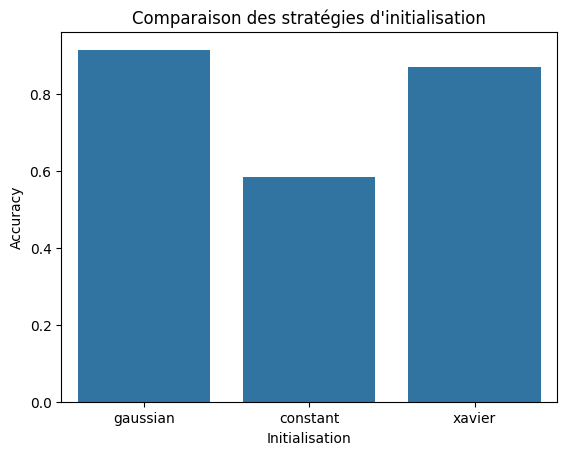

In [38]:
#Visualisation
sns.barplot(data=results_df,
            x='Initialisation',
            y='Accuracy')

plt.title("Comparaison des stratégies d'initialisation")
plt.show()

## Inspection, sauvegarde et rechargement du modèle

In [ ]:
#Inspection des paramètres
for name, param in model.named_parameters():
    print(name, param.shape)
# named_parameters() : renvoie tous les poids/biais "apprenables" du modèle, avec leur nom et leur forme (shape)
# Utile pour vérifier l'architecture réelle du modèle et estimer le nombre total de paramètres

fc1.weight torch.Size([128, 13])
fc1.bias torch.Size([128])
bn1.weight torch.Size([128])
bn1.bias torch.Size([128])
fc2.weight torch.Size([64, 128])
fc2.bias torch.Size([64])
bn2.weight torch.Size([64])
bn2.bias torch.Size([64])
fc3.weight torch.Size([2, 64])
fc3.bias torch.Size([2])


In [ ]:
#Afficher state_dict
print(model.state_dict().keys())
# state_dict() : dictionnaire ordonné {nom_du_paramètre: tenseur de valeurs}
# Contient uniquement les poids/biais (pas l'architecture du modèle) -> c'est ce qu'on sauvegarde habituellement

odict_keys(['fc1.weight', 'fc1.bias', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'fc2.weight', 'fc2.bias', 'bn2.weight', 'bn2.bias', 'bn2.running_mean', 'bn2.running_var', 'bn2.num_batches_tracked', 'fc3.weight', 'fc3.bias'])


In [ ]:
#Sauvegarde

torch.save(model.state_dict(), "best_model.pth")
# On sauvegarde uniquement les poids (state_dict), pas l'objet modèle complet
# -> fichier plus léger et plus portable (bonne pratique recommandée par PyTorch)

print("Modèle sauvegardé avec succès")

Modèle sauvegardé avec succès


In [ ]:
#. Recharger le modèle
loaded_model = MLP(input_dim, num_classes).to(device)
# Pour recharger les poids, il faut d'abord recréer une architecture IDENTIQUE à celle sauvegardée
# (state_dict ne contient pas la définition de la classe MLP, seulement les valeurs des poids)

In [ ]:
loaded_model.load_state_dict(torch.load("best_model.pth"))
# charge les poids sauvegardés depuis "best_model.pth" et les copie dans loaded_model

loaded_model.eval()
# passe le modèle en mode évaluation (désactive Dropout, BatchNorm utilise les statistiques apprises)
# étape indispensable avant toute prédiction/inférence

print("Modèle rechargé avec succès")

Modèle rechargé avec succès


In [ ]:
#Vérification CPU / GPU


print("Device du modèle :", next(model.parameters()).device)
print("Device des données :", X_test.device)
# Vérifie que le modèle et les données sont bien sur le même device
# (sinon PyTorch renverrait une erreur du type "expected all tensors to be on the same device")

Device du modèle : cpu
Device des données : cpu


## Évaluation finale (avec le modèle rechargé)

On vérifie que `loaded_model` (rechargé depuis le fichier `best_model.pth`) reproduit bien les mêmes performances que le modèle original, ce qui confirme que la sauvegarde/rechargement n'a fait perdre aucune information.

In [ ]:
#Évaluation finale complète
with torch.no_grad():
    outputs = loaded_model(X_test)
    y_pred = torch.argmax(outputs, axis=1)
    # On utilise ici loaded_model (et non plus model) pour vérifier que le rechargement
# des poids donne bien les mêmes prédictions que le modèle original avant sauvegarde

In [46]:
#Accuracy, Precision, Recall, F1
print("Accuracy :", accuracy_score(y_test.cpu(), y_pred.cpu()))
print("Precision :", precision_score(y_test.cpu(), y_pred.cpu()))
print("Recall :", recall_score(y_test.cpu(), y_pred.cpu()))
print("F1-score :", f1_score(y_test.cpu(), y_pred.cpu()))

Accuracy : 0.8376623376623377
Precision : 0.8214285714285714
Recall : 0.8734177215189873
F1-score : 0.8466257668711656


In [ ]:
#Rapport de classification
print(classification_report(y_test.cpu(), y_pred.cpu()))
# classification_report : résume precision/recall/F1-score/support pour CHAQUE classe séparément,
# plus les moyennes globales (macro avg, weighted avg) -> vue d'ensemble en un seul tableau

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        75
           1       0.82      0.87      0.85        79

    accuracy                           0.84       154
   macro avg       0.84      0.84      0.84       154
weighted avg       0.84      0.84      0.84       154



## Comparaison finale : `nn.Sequential` vs classe personnalisée

Les deux modèles (`model_seq` et `model`) ont exactement la **même architecture**. L'objectif ici est de comparer leur accuracy finale sur le test set — en gardant à l'esprit que `model` a été entraîné plus longtemps que `model_seq` (voir remarque plus haut).

In [ ]:
#Accuracy du modèle Sequential
model_seq.eval()

with torch.no_grad():
    outputs_seq = model_seq(X_test)
    pred_seq = torch.argmax(outputs_seq, axis=1)

acc_seq = accuracy_score(y_test.cpu(), pred_seq.cpu())

print("Accuracy Sequential :", acc_seq)
# model_seq a été entraîné sur 50 époques (une seule boucle d'entraînement)

Accuracy Sequential : 0.8766233766233766


In [ ]:
#Accuracy du modèle personnalisé
model.eval()

with torch.no_grad():
    outputs_custom = model(X_test)
    pred_custom = torch.argmax(outputs_custom, axis=1)

acc_custom = accuracy_score(y_test.cpu(), pred_custom.cpu())

print("Accuracy Classe personnalisée :", acc_custom)
# 'model' a en réalité été entraîné sur 100 époques au total (50 + 50, cf. remarque plus haut)
# La comparaison avec model_seq (50 époques) n'est donc pas parfaitement équitable

Accuracy Classe personnalisée : 0.8376623376623377


In [ ]:
#Maintenant refais le tableau
comparison = pd.DataFrame({
    'Modèle': ['Sequential', 'Classe personnalisée'],
    'Accuracy': [acc_seq, acc_custom]
})

print(comparison)

                 Modèle  Accuracy
0            Sequential  0.876623
1  Classe personnalisée  0.837662


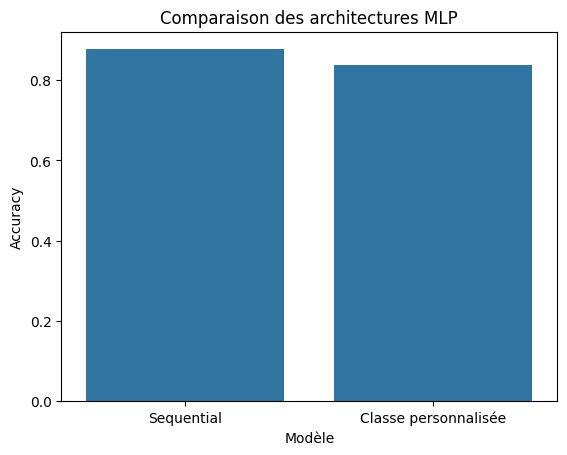

In [ ]:
sns.barplot(data=comparison, x='Modèle', y='Accuracy')
plt.title("Comparaison des architectures MLP")
plt.show()
# nn.Sequential et la classe personnalisée définissent ici la MÊME architecture
# -> les éventuelles différences d'accuracy viennent surtout du nombre d'époques d'entraînement
#    (et de l'aléatoire de l'initialisation des poids), pas d'une vraie différence d'architecture